# Learning Magic‑Formula Parameters with a Conditional DDIM
This notebook shows **a minimal working example** of using a *conditional Denoising Diffusion Implicit Model (DDIM)* to learn the four parameters (B, C, D, E) of the Pacejka *Magic Formula* for the friction–slip curve of an anti‑lock braking system (ABS), **conditioned on five noisy measurements**.

⚠️ *Because we only condition on five data points, this is purely an educational toy example—not production code.*

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import lr_scheduler
import torch.optim as optim

n_cond = 5  # number of samples to act as the condition for the diffusion model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
params_encoding = {
    0: "D",
    1: "C",
    2: "B",
    3: "E"
}

In [ ]:
def magic_formula(slip, params):
    """Return mu given slip (tensor) and params = (B,C,D,E)."""
    D, C, B, E = params.to(device).unbind(-1)
    return D * torch.sin(C * torch.atan(B * slip - E * (B * slip - torch.atan(B * slip)) ) )

In [ ]:
def make_batch(batch_size=64, n_cond=n_cond, noise_std=0.05, slip_range=(0.0, 1.0)):
    """Generate a batch of (params, condition) pairs.

    * params: true (B,C,D,E) ∈ ℝ⁴
    * condition: noisy (slip, mu) pairs generated from each set of BCDE
    """
    # Sample random ground‑truth parameters from realistic ranges
    B = torch.empty(batch_size, 1, device=device).uniform_(4.0, 12.0)
    C = torch.empty(batch_size, 1, device=device).uniform_(1.0, 2.0)
    D = torch.empty(batch_size, 1, device=device).uniform_(0.1, 1.9)
    E = torch.empty(batch_size, 1, device=device).uniform_(-1.0, 1.0)
    params = torch.cat([D, C, B, E], dim=1)

    # Generate n_cond pairs of (slip, mu) for each BCDE
    slip = (torch.rand(batch_size, n_cond, device=device)) * (slip_range[1] - slip_range[0])  + slip_range[0]
    # slip = torch.linspace(slip_range[0], slip_range[1], n_cond).repeat(batch_size, 1)
    sorted_slip, _ = torch.sort(slip, dim=1)
    mu = magic_formula(sorted_slip, params.unsqueeze(1).expand(-1, n_cond, -1))
    mu_noisy = mu + noise_std * torch.randn_like(mu)

    cond = torch.cat([sorted_slip, mu_noisy], dim=-1).reshape(batch_size, 2, -1)
    return params.to(device), cond.to(device)

/var/folders/50/2xnlv1wx4_91lvzqtbrvx_yc0000gn/T/ipykernel_19683/3270393090.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


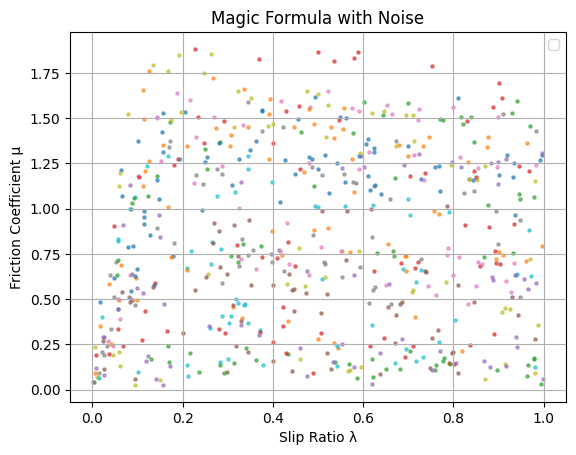

In [ ]:
ata_param, data_slip = make_batch()
for i in range(data_param.shape[0]):
    slips, mu_noisy = data_slip[i, 0, :], data_slip[i, 1, :]

    # Plot the Magic Formula
    plt.scatter(slips.cpu(), mu_noisy.cpu(), alpha=0.6, s=5)

plt.xlabel('Slip Ratio λ')
plt.ylabel('Friction Coefficient μ')
plt.title('Magic Formula with Noise')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
## Diffusion schedule
T = 1000
beta_start, beta_end = 1e-4, 0.025
betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


## Determining the scale and shift parameters used to tranform B,C,D,E in [0,1]
range_b = (4.0, 12.0)
range_c = (1.0, 2.0)
range_d = (0.1, 1.9)
range_e = (-1.0, 1.0)
scale = torch.tensor([(range_d[1] - range_d[0]), range_c[1] - range_c[0],
                      range_b[1] - range_b[0], (range_e[1] - range_e[0])]).to(data_param.device)
shift = torch.tensor([range_b[0], range_c[0],
                      range_d[0], range_e[0]]).to(data_param.device)

In [ ]:
def q_sample(x0, t, noise=None):
    """Diffusion forward process q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0, device=device)
    sqrt_alphas_cumprod = (alphas_cumprod[t]**0.5).unsqueeze(1).to(device).expand_as(x0)
    sqrt_one_minus_alphas_cumprod = ((1 - alphas_cumprod[t])**0.5).unsqueeze(1).to(device).expand_as(x0)

    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas_cumprod * noise, noise

In [ ]:
class CondMLP(nn.Module):
    def __init__(self, cond_dim=2*n_cond, x_dim=4, hidden1=128, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + cond_dim + 1, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Linear(hidden2, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, x_dim)
        )
        # self.net = nn.Sequential(
        #     nn.Linear(x_dim + cond_dim + 1, 3200),
        #     nn.Sigmoid(),
        #     # nn.Linear(hidden1, hidden2),
        #     # nn.ReLU(),
        #     # nn.Linear(hidden2, hidden2),
        #     # nn.ReLU(),
        #     nn.Linear(3200, x_dim)
        # )
    def forward(self, x_t, t, cond):
        # Embed timestep as (t / T) to 1‑D scalar
        t_embed = (t.float() / T).unsqueeze(-1)
        inp = torch.cat([x_t, cond, t_embed], dim=-1)
        return self.net(inp)

In [ ]:
def ddim_sample(model, cond, n_steps=1000, eta=0.0, params_num=4):
  x = torch.randn(cond.shape[0], params_num, device=cond.device)
  step_size = T // n_steps
  for i in range(T-1, -1, -step_size):
    t = torch.full((cond.size(0),), i, device=cond.device, dtype=torch.long)
    noise_pred = model(x, t, cond)

    alpha_bar = alphas_cumprod[i]
    i_prev = max(i - step_size, 0)
    alpha_bar_prev = alphas_cumprod[i_prev]

    # Predict x_0
    x0_pred = (x - torch.sqrt(1 - alpha_bar) * noise_pred) / torch.sqrt(alpha_bar) * torch.sqrt(alpha_bar_prev)


    # DDIM coefficients
    sigma = 0.0
    if eta > 0:
      sigma = (
        eta
        * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar))
        * torch.sqrt(1 - alpha_bar / alpha_bar_prev)
      )

    dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * noise_pred
    x = dir_xt + x0_pred
    if eta > 0:
      x = x + sigma * torch.randn_like(x)
  return x0_pred

In [ ]:
model_d = CondMLP().to(device)

epochs1, batch_size1 = 30000, 1024
epochs2, inner_epochs, batch_size2, n_cond2 = 30, 50, 8192, 100

# Initialize a learning rate scheduler (e.g., StepLR)
optimizer1 = torch.optim.RMSprop(model.parameters(), lr=1e-3)
scheduler1 = lr_scheduler.StepLR(optimizer1, step_size=epochs1/3, gamma=0.1)

optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler2 = lr_scheduler.StepLR(optimizer2, step_size=epochs2/3, gamma=0.1)
l1_loss = nn.L1Loss()

In [ ]:
sample_size = 1000

@torch.no_grad()
def draw(model, params_num=4):
  slips = torch.linspace(0, 1, sample_size, device=device)
  slips_np = slips.detach().cpu().numpy()
  fig, axes = plt.subplots(1, 10, figsize=(40, 4))
  for i in range(10):
      # Generate new ground-truth parameters and noisy condition
      true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.03)
      slips_i, mu_true = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
      # Estimate parameters using DDIM
      est_params_i = ddim_sample(model, cond_test_i.reshape(1, -1), n_steps=T).squeeze()
      if params_num == 3:
        ds = true_params_i[:, 0]
        est_params_i = torch.cat([ds, est_params_i], dim=-1)

      # Compute mu for a range of slips
      mu_true_i = magic_formula(slips, true_params_i).detach().cpu().numpy()
      mu_est_i = magic_formula(slips, est_params_i).detach().cpu().numpy()
      # Plot
      axes[i].plot(slips_np, mu_true_i, label='True μ')
      axes[i].plot(slips_np, mu_est_i, label='Estimated μ')
      axes[i].scatter(slips_i.detach().cpu().numpy(), mu_true.detach().cpu().numpy(), label='Conditions', s=10)
      axes[i].set_xlabel('Slip Ratio λ')
      axes[i].set_ylabel('Friction Coefficient μ')
      axes[i].set_title(f'Magic Formula: Example {i+1}')
      axes[i].legend()
      axes[i].grid(True)
  plt.tight_layout()
  plt.show()
  
  
  fig, axes = plt.subplots(1, 5, figsize=(15, 5))

  # Generate new ground-truth parameters and noisy condition
  true_params, cond_test = make_batch(sample_size, n_cond, noise_std=0.0)
  slips, mu_true = cond_test[:, 0, :], cond_test[:, 1, :]
  # Estimate parameters using DDIM
  est_params = ddim_sample(model, cond_test.reshape(sample_size, -1), n_steps=T).squeeze()
  if params_num == 3:
    ds = true_params_i[:, 0]
    est_params_i = torch.cat([ds, est_params_i], dim=-1)
  ds_true = true_params[:, 0]
  cs_true = true_params[:, 1]
  bs_true = true_params[:, 2]
  es_true = true_params[:, 3]

  ds_pred = est_params[:, 0]
  cs_pred = est_params[:, 1]
  bs_pred = est_params[:, 2]
  es_pred = est_params[:, 3]


  for j in range(4):
    axes[j].scatter(true_params[:, j].detach().cpu().numpy(), est_params[:, j].detach().cpu().numpy(), alpha=0.5, s=5)
    axes[j].set_xlabel(f'True Param {params_encoding[j]}')
    axes[j].set_ylabel(f'Estimated Param {params_encoding[j]}')
    axes[j].set_title(f'Param {params_encoding[j]} Estimation')
    axes[j].grid(True)
  
  axes[0].set_xlim(range_b[0], range_b[1])
  axes[0].set_ylim(range_b[0], range_b[1])
  axes[1].set_xlim(range_c[0], range_c[1])
  axes[1].set_ylim(range_c[0], range_c[1])
  axes[2].set_xlim(range_d[0], range_d[1])
  axes[2].set_ylim(range_d[0], range_d[1])
  axes[3].set_xlim(range_e[0], range_e[1])  
  axes[3].set_ylim(range_e[0], range_e[1])
  
  axes[4].scatter(bs_true * cs_true * ds_true, bs_pred * cs_pred * ds_pred, s=10)
  axes[4].set_xlabel(f'True BCD')
  axes[4].set_ylabel(f'Estimated BCD')
  axes[4].set_title(f'BCD Estimation')
  axes[4].grid(True)
  axes[4].set_xlim(0, 40)
  axes[4].set_ylim(0, 40)

  # plt.legend()
  plt.show()

  print("b r2:", 1 - F.mse_loss(bs_pred, bs_true) / torch.var(bs_true))
  print("c r2:", 1 - F.mse_loss(cs_pred, cs_true) / torch.var(cs_true))
  print("d r2:", 1 - F.mse_loss(ds_pred, ds_true) / torch.var(ds_true))
  print("e r2:", 1 - F.mse_loss(es_pred, es_true) / torch.var(es_true))

In [ ]:
for step in range(1, epochs1+1):
  # Generating batches of params_0=(B,C,D,E),
  # cond=(slip, mu) pairs for each set of params, and time step t
  params_0, cond = make_batch(batch_size1, noise_std=0.03)
  slips, mu_true = cond[:, 0, :], cond[:, 1, :]
  t = torch.randint(0, T, (batch_size1,), device=device)

  # Generating the noisy params for time step t
  x_t, noise = q_sample(params_0, t)

  # forward process the model to generate an estimated noise
  noise_pred = model_d(x_t, t, cond.reshape(batch_size1, -1))

  loss1 = F.mse_loss(noise_pred, noise)

  optimizer1.zero_grad()
  loss1.backward()
  optimizer1.step()

  # Update the learning rate
  scheduler1.step()

  if step % (epochs1 // epochs2) == 0:
    for _ in range(inner_epochs):
      params, cond = make_batch(batch_size2, noise_std=0.03)
      Ds, Cs, Bs, Es = params[:, 0], params[:, 1], params[:, 2], params[:, 3]

      # Estimate parameters using DDIM
      est_params = ddim_sample(model_d, cond.reshape(batch_size2, -1), n_steps=50).squeeze()
      est_Ds, est_Cs, est_Bs, est_Es = est_params[:, 0], est_params[:, 1], est_params[:, 2], est_params[:, 3]

      slips = torch.linspace(0, 1, n_cond2, device=device)
      mu_true = magic_formula(slips, params.unsqueeze(1).expand(-1, n_cond2, -1))
      mu_est = magic_formula(slips, est_params.unsqueeze(1).expand(-1, n_cond2, -1))

      shifted_est_params = (est_params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)
      shifted_true_params = (params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)

      mse_mu = F.mse_loss(mu_true, mu_est)
      mse_params = F.mse_loss(shifted_est_params, shifted_true_params)
      rel_Bs = F.relu(4.0 - est_Bs).mean() + F.relu(est_Bs - 12.0).mean()
      rel_Cs = F.relu(1.0 - est_Cs).mean() + F.relu(est_Cs - 2.0).mean()
      rel_Ds = F.relu(0.1 - est_Ds).mean() + F.relu(est_Ds - 1.9).mean()
      rel_Es = F.relu(-1.0 - est_Es).mean() + F.relu(est_Es - 1.0).mean()

      loss2 = mse_mu + mse_params + rel_Bs + rel_Cs + rel_Ds + rel_Es

      optimizer2.zero_grad()
      loss2.backward()
      optimizer2.step()

    scheduler2.step()

    if step % (epochs1 // epochs2) == 0:
      print(f"step {step:5d} | loss1 {loss1.item():.4e} | loss2 {loss2.item():.4e} | lr1 {optimizer1.param_groups[0]['lr']:.4e} | lr2 {optimizer2.param_groups[0]['lr']:.4e}")

    if step % (30 * epochs1 // epochs2) == 0:
    #   plt.bar(range(7), [mse_mu.item(), mse_params.item(), 0,
    #               rel_Bs.item(), rel_Cs.item(), rel_Ds.item(), rel_Es.item()])
    #   plt.xticks(range(7), ['mse_mu', 'mse_params', 'mse_BCDs', 'rel_Bs', 'rel_Cs', 'rel_Ds', 'rel_Es'])
    #   plt.ylabel('Loss')
    #   plt.title(f'Step {step}')
    #   plt.show()
      draw(model_d)

mse_mu: 1.6558e+02, mse_params: 1.9536e+02, mse_BCDs: 2.9775e+04
mse_mu: 9.4322e+01, mse_params: 1.9436e+02, mse_BCDs: 3.7684e+04
mse_mu: 3.4085e+02, mse_params: 2.2797e+02, mse_BCDs: 5.6391e+04
mse_mu: 2.3231e+02, mse_params: 1.6989e+02, mse_BCDs: 2.5098e+04
mse_mu: 8.9635e+01, mse_params: 1.2838e+02, mse_BCDs: 1.1476e+04
mse_mu: 5.6139e+01, mse_params: 1.1458e+02, mse_BCDs: 1.7796e+04
mse_mu: 4.3487e+01, mse_params: 1.1747e+02, mse_BCDs: 1.0196e+04
mse_mu: 6.8065e+01, mse_params: 9.2475e+01, mse_BCDs: 9.9932e+03
mse_mu: 1.9352e+02, mse_params: 1.2812e+02, mse_BCDs: 3.0754e+04
mse_mu: 6.5762e+01, mse_params: 1.0306e+02, mse_BCDs: 1.7724e+04
mse_mu: 9.1457e+01, mse_params: 1.4390e+02, mse_BCDs: 8.1103e+03
mse_mu: 1.4468e+02, mse_params: 2.3899e+02, mse_BCDs: 1.7195e+04
mse_mu: 9.4722e+01, mse_params: 1.3368e+02, mse_BCDs: 1.5379e+04
mse_mu: 3.3036e+02, mse_params: 2.5736e+02, mse_BCDs: 3.1424e+04
mse_mu: 1.2781e+02, mse_params: 2.5848e+02, mse_BCDs: 2.3700e+04
mse_mu: 5.1492e+01, mse_p

KeyboardInterrupt: 

## Next Steps
* Increase the training data size and epochs for better accuracy.
* Replace the simple MLP with a richer network (e.g. sinusoidal timestep embedding, FiLM‑style conditional layers).
* Explore alternative conditioning tricks such as cross‑attention.
* Try other diffusion formulations (e.g. Score‑SDE, DPM‑Solver) for faster sampling.

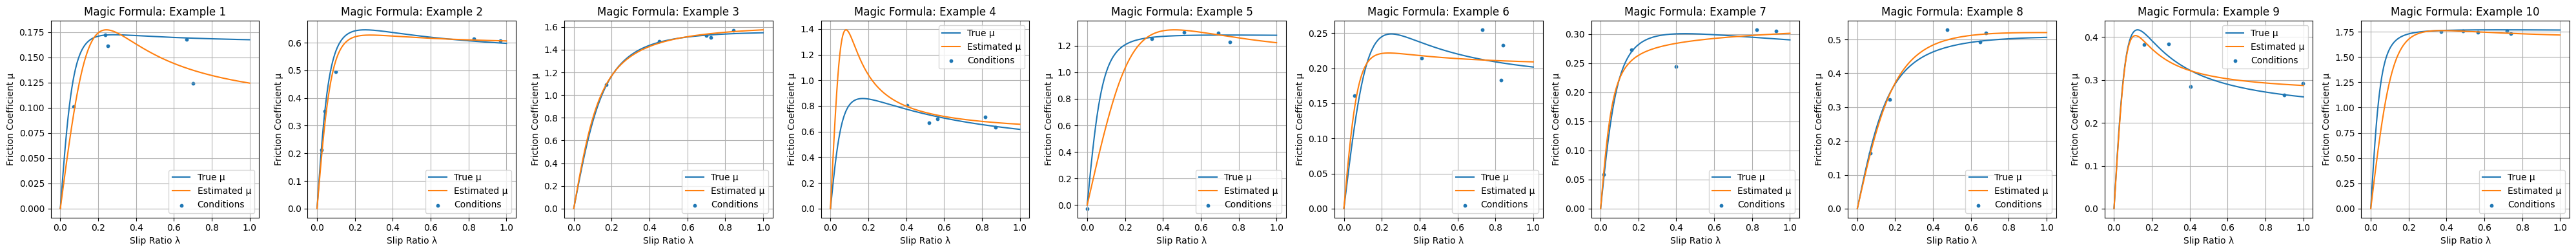

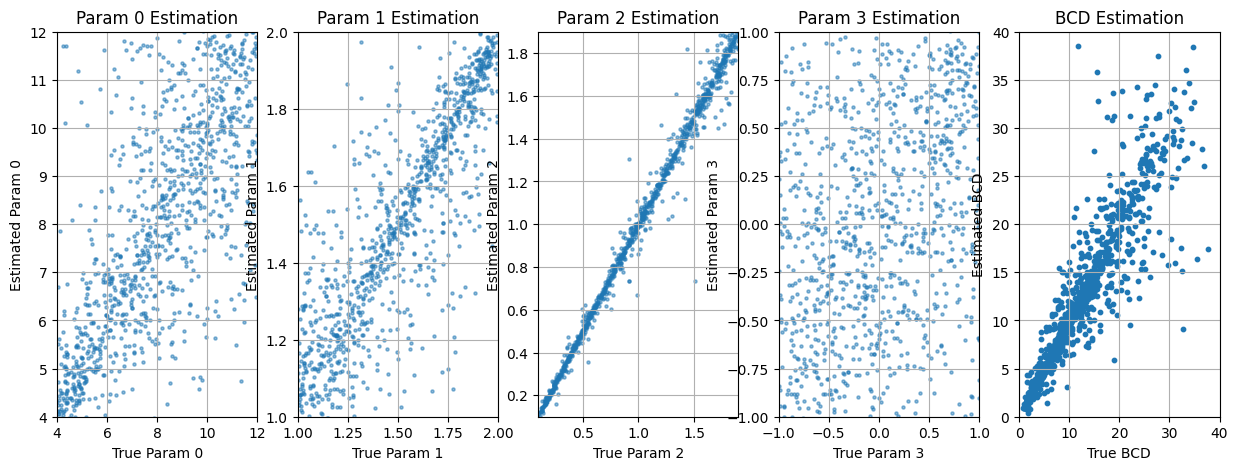

b r2: tensor(0.4195)
c r2: tensor(0.6673)
d r2: tensor(0.9882)
e r2: tensor(-0.3266)


In [23]:
model = torch.load('NN-5cond-128R128S128-noBCD-300K-300x50.pt', map_location=torch.device('cpu'), weights_only=False)
draw(model)

# Cascaded Diffusion Model

In [ ]:
class CondMLPBCE(nn.Module):
    def __init__(self, cond_dim=2*n_cond, x_dim=3, hidden1=128, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + cond_dim + 1, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Linear(hidden2, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, x_dim)
        )
    def forward(self, x_t, t, cond):
        # Embed timestep as (t / T) to 1‑D scalar
        t_embed = (t.float() / T).unsqueeze(-1)
        inp = torch.cat([x_t, cond, t_embed], dim=-1)
        return self.net(inp)

In [ ]:
model_bce = CondMLP2().to(device)

epochs1_bce, batch_size1_bce = 100000, 1024
epochs2_bce, inner_epochs_bce, batch_size2_bce, n_cond2_bce = 100, 50, 8192, 100

# Initialize a learning rate scheduler (e.g., StepLR)
optimizer1_bce = torch.optim.RMSprop(model_bce.parameters(), lr=1e-3)
scheduler1_bce = lr_scheduler.StepLR(optimizer1_bce, step_size=epochs1_bce/3, gamma=0.1)

optimizer2_bce = torch.optim.Adam(model_bce.parameters(), lr=1e-3)
scheduler2_bce = lr_scheduler.StepLR(optimizer2_bce, step_size=epochs2_bce/3, gamma=0.1)

In [ ]:
for step in range(1, epochs1_bce+1):
  # Generating batches of params_0=(B,C,D,E),
  # cond=(slip, mu) pairs for each set of params, and time step t
  params_0, cond = make_batch(batch_size1_bce, noise_std=0.03)
  slips, mu_true = cond[:, 0, :], cond[:, 1, :]
  ds = params_0[:, 0]
  mu_true = mu_true / ds.unsqueeze(1).expand(-1, n_cond)
  params = params_0[:, 1:]  # Exclude D from params for BCE loss
  
  t = torch.randint(0, T, (batch_size1_bce,), device=device)

  # Generating the noisy params for time step t
  x_t, noise = q_sample(params, t)

  # forward process the model to generate an estimated noise
  noise_pred = model_bce(x_t, t, cond.reshape(batch_size1_bce, -1))

  loss1 = F.mse_loss(noise_pred, noise)

  optimizer1_bce.zero_grad()
  loss1.backward()
  optimizer1_bce.step()

  # Update the learning rate
  scheduler1_bce.step()

  if step % (epochs1_bce // epochs2_bce) == 0:
    for _ in range(inner_epochs_bce):
      params, cond = make_batch(batch_size2_bce, noise_std=0.03)
      Ds, Cs, Bs, Es = params[:, 0], params[:, 1], params[:, 2], params[:, 3]
      slips, mu_true = cond[:, 0, :], cond[:, 1, :]
      mu_true = mu_true / Ds.unsqueeze(1).expand(-1, n_cond2)
      cond_adjusted = torch.cat([slips.unsqueeze(1), mu_true.unsqueeze(1)], dim=1).reshape(batch_size2_bce, -1)

      # Estimate parameters using DDIM
      est_params = ddim_sample(model_bce, cond_adjusted.reshape(batch_size2_bce, -1), n_steps=50, params_num=3).squeeze()
      est_Cs, est_Bs, est_Es = est_params[:, 0], est_params[:, 1], est_params[:, 2], est_params[:, 3]
      est_params = torch.cat([Ds.unsqueeze(1), est_params], dim=1)  # Include D in estimated params

      slips = torch.linspace(0, 1, n_cond2, device=device)
      mu_true = magic_formula(slips, params.unsqueeze(1).expand(-1, n_cond2, -1))
      mu_est = magic_formula(slips, est_params.unsqueeze(1).expand(-1, n_cond2, -1))

      shifted_est_params = (est_params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)
      shifted_true_params = (params - shift.T.repeat(batch_size2, 1)) / scale.T.repeat(batch_size2, 1)

      mse_mu = F.mse_loss(mu_true, mu_est)
      mse_params = F.mse_loss(shifted_est_params, shifted_true_params)
      rel_Bs = F.relu(4.0 - est_Bs).mean() + F.relu(est_Bs - 12.0).mean()
      rel_Cs = F.relu(1.0 - est_Cs).mean() + F.relu(est_Cs - 2.0).mean()
      rel_Es = F.relu(-1.0 - est_Es).mean() + F.relu(est_Es - 1.0).mean()

      loss2 = mse_mu + mse_params + rel_Bs + rel_Cs + rel_Es

      optimizer2_bce.zero_grad()
      loss2.backward()
      optimizer2_bce.step()

    scheduler2_bce.step()

    if step % (epochs1_bce // epochs2_bce) == 0:
      print(f"step {step:5d} | loss1 {loss1.item():.4e} | loss2 {loss2.item():.4e} | lr1 {optimizer1_bce.param_groups[0]['lr']:.4e} | lr2 {optimizer2_bce.param_groups[0]['lr']:.4e}")

    if step % (30 * epochs1_bce // epochs2_bce) == 0:
      draw(model_bce, num_params=3)

# Testing


In [ ]:
sample_size = 1000
slips = np.linspace(0, 1, sample_size)
fig, axes = plt.subplots(1, 10, figsize=(40, 4))
for i in range(10):
    # Generate new ground-truth parameters and noisy condition
    true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.03)
    slips_i, mu_true = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
    # Estimate parameters using DDIM
    est_params_i = ddim_sample(model_d, cond_test_i.reshape(1, -1), n_steps=T).squeeze()
    
    est_ds = true_params_i[:, 0]
    mu_adjusted_i = mu_true / est_ds.unsqueeze(1).expand(-1, n_cond)
    cond_adjusted_i = torch.cat([slips_i.unsqueeze(1), mu_adjusted_i.unsqueeze(1)], dim=1).reshape(1, -1)
    est_params_i_bce = ddim_sample(model_bce, cond_adjusted_i, n_steps=50, params_num=3).squeeze()
    est_params_i = torch.cat([est_ds, est_params_i_bce], dim=-1)

    # Compute mu for a range of slips
    mu_true_i = magic_formula(torch.tensor(slips, device=device), true_params_i).detach().cpu().numpy()
    mu_est_i = magic_formula(torch.tensor(slips, device=device), est_params_i).detach().cpu().numpy()
    # Plot
    axes[i].plot(slips, mu_true_i, label='True μ')
    axes[i].plot(slips, mu_est_i, label='Estimated μ')
    axes[i].scatter(slips_i.detach().cpu().numpy(), mu_true.detach().cpu().numpy(), label='Conditions', s=10)
    axes[i].set_xlabel('Slip Ratio λ')
    axes[i].set_ylabel('Friction Coefficient μ')
    axes[i].set_title(f'Magic Formula: Example {i+1}')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sample_size = 1000
# Generate new ground-truth parameters and noisy condition
true_params, cond_test = make_batch(sample_size, n_cond, noise_std=0.0)
slips, mu_true = cond_test[:, 0, :], cond_test[:, 1, :]
# Estimate parameters using DDIM
est_params = ddim_sample(model_d, cond_test.reshape(sample_size, -1), n_steps=T).squeeze()

est_ds = true_params[:, 0]
mu_adjusted = mu_true / est_ds.unsqueeze(1).expand(-1, n_cond)
cond_adjusted = torch.cat([slips.unsqueeze(1), mu_adjusted.unsqueeze(1)], dim=1).reshape(sample_size, -1)
est_params_i_bce = ddim_sample(model_bce, cond_adjusted, n_steps=50, params_num=3).squeeze()
est_params = torch.cat([est_ds.unsqueeze(1), est_params_i_bce], dim=-1)

ds_true = true_params[:, 0]
cs_true = true_params[:, 1]
bs_true = true_params[:, 2]
es_true = true_params[:, 3]

ds_pred = est_params[:, 0]
cs_pred = est_params[:, 1]
bs_pred = est_params[:, 2]
es_pred = est_params[:, 3]


for j in range(4):
  axes[j].scatter(true_params[:, j].detach().cpu().numpy(), est_params[:, j].detach().cpu().numpy(), alpha=0.5, s=5)
  axes[j].set_xlabel(f'True Param {params_encoding[j]}')
  axes[j].set_ylabel(f'Estimated Param {params_encoding[j]}')
  axes[j].set_title(f'Param {params_encoding[j]} Estimation')
  axes[j].grid(True)

# plt.legend()
plt.show()

print("b r2:", 1 - F.mse_loss(bs_pred, bs_true) / torch.var(bs_true))
print("c r2:", 1 - F.mse_loss(cs_pred, cs_true) / torch.var(cs_true))
print("d r2:", 1 - F.mse_loss(ds_pred, ds_true) / torch.var(ds_true))
print("e r2:", 1 - F.mse_loss(es_pred, es_true) / torch.var(es_true))